# Compare 0512 Filter Modes vs GT from OpenSim ID

This notebook replays IK->ID checkpoints for the 0512 sweep settings on telemetry `.npz` files using right-side raw model inputs:
- hip: `model_in_angle_raw`, `model_in_vel_raw`
- knee: `model_in_knee_angle_raw`, `model_in_knee_vel_raw`

For each sweep mode, we:
1. preprocess inputs according to setting (`zero_phase` / `causal`),
2. run checkpoint inference,
3. process output according to setting (`none` / `zero_phase` / `causal`),
4. compare prediction against GT loaded from the subject OpenSim `id` folder.

OpenSim `id` moments are converted from **Nm** to **Nm/kg** using the configured subject mass value.

Telemetry and OpenSim timelines are synced by the first GPIO rising edge using telemetry `gpio_output` (fallback: `GPIO`) and mocap `trig - Electric Potential` (fallback: `jet`).

Separate sections are provided for hip exo and knee exo.

In [33]:
from __future__ import annotations

import io
import json
import inspect
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import csv

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Image
from scipy.signal import butter, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
SUBJECTS_ROOT = PROJECT_ROOT.parent

# OpenSim ID moments are in Nm. Convert GT to Nm/kg with subject mass.
# You can override per subject key (e.g., 'ab02_oscar').
SUBJECT_MASS_KG_DEFAULT = 88.0
SUBJECT_MASS_KG_BY_SUBJECT = {
    'ab01_jinwoo': 88.0,
    'ab02_oscar': 71.1,
    'ab03_ilseung': 84.4,
    'ab04_changseob': 74.0,
    'ab08_seokhyun': 71.9
}

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model import TCN


def _safe_torch_load(path: Path):
    try:
        return torch.load(str(path), map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(str(path), map_location='cpu')


def tcn_kwargs(model_config: Dict) -> Dict:
    allowed = {k for k in inspect.signature(TCN.__init__).parameters if k != 'self'}
    return {k: v for k, v in model_config.items() if k in allowed}


def infer_fs_hz(time_s: np.ndarray, default_fs: float = 100.0) -> float:
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        return float(default_fs)
    return float(1.0 / np.median(dt))


def delay_series_seconds(x: np.ndarray, fs_hz: float, delay_s: float) -> np.ndarray:
    y = np.asarray(x, dtype=np.float32).copy()
    delay_samples = int(round(float(delay_s) * float(fs_hz)))
    if delay_samples <= 0:
        return y
    if delay_samples >= y.size:
        return np.full_like(y, np.nan, dtype=np.float32)

    out = np.full_like(y, np.nan, dtype=np.float32)
    out[delay_samples:] = y[:-delay_samples]
    return out


def butter_lpf_series(x: np.ndarray, fs_hz: float, cutoff_hz: float, order: int, mode: str) -> np.ndarray:
    mode = str(mode)
    if mode not in {'zero_phase', 'causal'}:
        raise ValueError(f'Unsupported LPF mode: {mode}')
    arr = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * float(fs_hz)
    if (not np.isfinite(nyq)) or nyq <= 0 or cutoff_hz <= 0 or cutoff_hz >= nyq:
        return arr.astype(np.float32)
    sos = butter(int(order), float(cutoff_hz) / nyq, btype='low', output='sos')
    if mode == 'zero_phase':
        y = sosfiltfilt(sos, arr)
    else:
        y = sosfilt(sos, arr)
    return np.asarray(y, dtype=np.float32)


def apply_mode_lpf(x: np.ndarray, fs_hz: float, cutoff_hz: float, order: int, mode: str) -> np.ndarray:
    if str(mode) == 'none':
        return np.asarray(x, dtype=np.float32)
    return butter_lpf_series(x, fs_hz, cutoff_hz, order, mode)


GT_LPF_CUTOFF_HZ = 6.0
GT_LPF_ORDER = 4
GT_LPF_MODE = 'zero_phase'

# OpenSim right-joint-moment sign convention mapped to model target sign.
HIP_GT_SIGN = +1.0
KNEE_DEFAULT_GT_SIGN = +1.0
KNEE_RD_GT_SIGN = +1.0

CMP_OUT_LPF_CUTOFF_HZ = 6.0
CMP_OUT_LPF_ORDER = 4
CMP_OUT_LPF_MODE = 'zero_phase'


def lpf_series_preserve_nan(
    x: np.ndarray,
    fs_hz: float,
    cutoff_hz: float,
    order: int,
    mode: str,
) -> np.ndarray:
    """LPF a series while preserving NaN mask."""
    arr = np.asarray(x, dtype=np.float32).copy()
    finite = np.isfinite(arr)
    if int(np.count_nonzero(finite)) < max(3, int(order) + 1):
        return arr

    if np.all(finite):
        return butter_lpf_series(arr, fs_hz, cutoff_hz, order, mode)

    idx = np.arange(arr.size, dtype=np.float64)
    filled = np.interp(idx, idx[finite], arr[finite]).astype(np.float32)
    filt = butter_lpf_series(filled, fs_hz, cutoff_hz, order, mode)
    filt = np.asarray(filt, dtype=np.float32)
    filt[~finite] = np.nan
    return filt


def run_tcn_last_step(model: TCN, angle: np.ndarray, vel: np.ndarray, window_size: int, device: str) -> np.ndarray:
    n = int(min(len(angle), len(vel)))
    pred = np.zeros(n, dtype=np.float32)
    model.eval()
    with torch.no_grad():
        for t in range(n):
            start = max(0, t - window_size + 1)
            valid = t - start + 1
            x = np.zeros((2, window_size), dtype=np.float32)
            x[0, -valid:] = angle[start:t + 1]
            x[1, -valid:] = vel[start:t + 1]
            xt = torch.from_numpy(x).unsqueeze(0).to(device=device, dtype=torch.float32)
            y = model(xt)
            pred[t] = float(y[0, 0, -1].item())
    return pred


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    y_t = np.asarray(y_true, dtype=np.float64)
    y_p = np.asarray(y_pred, dtype=np.float64)
    m = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[m]
    y_p = y_p[m]
    if y_t.size == 0:
        return {'n': 0, 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'corr': np.nan}

    err = y_p - y_t
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))
    y_mean = float(np.mean(y_t))
    ss_tot = float(np.sum((y_t - y_mean) ** 2))
    ss_res = float(np.sum(err ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))

    if y_t.size < 3:
        corr = float('nan')
    else:
        yt0 = y_t - np.mean(y_t)
        yp0 = y_p - np.mean(y_p)
        denom = float(np.linalg.norm(yt0) * np.linalg.norm(yp0))
        corr = float(np.dot(yt0, yp0) / (denom + 1e-12))

    return {'n': int(y_t.size), 'rmse': rmse, 'mae': mae, 'r2': r2, 'corr': corr}


def _read_opensim_sto_table(sto_path: Path) -> Tuple[List[str], np.ndarray]:
    with open(sto_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    end_idx = None
    for i, line in enumerate(lines):
        if line.strip().lower() == 'endheader':
            end_idx = i
            break
    if end_idx is None or end_idx + 2 >= len(lines):
        raise ValueError(f'Invalid .sto format: {sto_path}')

    col_names = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])), dtype=np.float64)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] != len(col_names):
        raise ValueError(
            f'Column count mismatch in {sto_path}: header={len(col_names)} data={data.shape[1]}'
        )
    return col_names, data


def _subject_token_from_trial_stem(trial_stem: str) -> str:
    parts = trial_stem.lower().split('_')
    if len(parts) < 2:
        raise ValueError(f'Unexpected telemetry filename stem: {trial_stem}')
    return '_'.join(parts[:2])


def _subject_dir_from_trial_stem(trial_stem: str) -> Path:
    subj_token = _subject_token_from_trial_stem(trial_stem)
    for p in SUBJECTS_ROOT.glob('AB*_*'):
        if p.is_dir() and p.name.lower() == subj_token:
            return p
    raise FileNotFoundError(f'Could not resolve subject folder for {subj_token!r} under {SUBJECTS_ROOT}')


def _subject_mass_kg_from_trial_stem(trial_stem: str) -> float:
    subj_token = _subject_token_from_trial_stem(trial_stem)
    mass = float(SUBJECT_MASS_KG_BY_SUBJECT.get(subj_token, SUBJECT_MASS_KG_DEFAULT))
    if not np.isfinite(mass) or mass <= 0.0:
        raise ValueError(f'Invalid subject mass for {subj_token}: {mass}')
    return mass


def _trial_cond_speed_tokens(telemetry_npz: Path) -> Tuple[str, str]:
    stem = telemetry_npz.stem.lower()
    parts = stem.split('_')
    if len(parts) < 5:
        raise ValueError(f'Unexpected telemetry filename stem: {stem}')
    speed = parts[3]
    cond = parts[4].upper()
    return cond, speed


def _resolve_id_sto_path(telemetry_npz: Path, exo_kind: str) -> Path:
    cond, speed = _trial_cond_speed_tokens(telemetry_npz)

    subject_dir = _subject_dir_from_trial_stem(telemetry_npz.stem)
    id_dir = subject_dir / exo_kind / 'id'
    if not id_dir.exists():
        raise FileNotFoundError(f'ID folder not found: {id_dir}')

    exact = id_dir / f'{cond}_{speed}_id.sto'
    if exact.exists():
        return exact

    cands = sorted(id_dir.glob(f'*_{speed}_id.sto'))
    if not cands:
        raise FileNotFoundError(f'No ID .sto match for speed {speed!r} in {id_dir}')

    for p in cands:
        if p.name.lower().startswith(f'{cond.lower()}_'):
            return p

    return cands[0]


def _resolve_mocap_csv_path(telemetry_npz: Path, exo_kind: str) -> Path:
    cond, speed = _trial_cond_speed_tokens(telemetry_npz)
    subject_dir = _subject_dir_from_trial_stem(telemetry_npz.stem)
    mocap_dir = subject_dir / exo_kind / 'mocap'
    if not mocap_dir.exists():
        raise FileNotFoundError(f'Mocap folder not found: {mocap_dir}')

    exact = mocap_dir / f'{cond}_{speed}.csv'
    if exact.exists():
        return exact

    cands = sorted(mocap_dir.glob(f'*_{speed}.csv'))
    if not cands:
        raise FileNotFoundError(f'No mocap CSV match for speed {speed!r} in {mocap_dir}')

    for p in cands:
        if p.stem.lower().startswith(f'{cond.lower()}_'):
            return p

    return cands[0]


def _parse_mocap_trigger_csv(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    with open(path, 'r', encoding='utf-8') as f:
        _ = f.readline()  # "Devices"
        fs_hz = 1000.0
        try:
            fs_hz = float(f.readline().strip().split(',')[0])
        except Exception:
            pass
        _ = f.readline()  # group header
        header_row = f.readline().strip().split(',')
        _ = f.readline()  # units row

        trig_idx = None
        for cand in ('trig - Electric Potential', 'jet', 'trig', 'gpio'):
            if cand in header_row:
                trig_idx = header_row.index(cand)
                break
        if trig_idx is None:
            raise KeyError(f'Could not find trigger column in mocap CSV: {path.name}')

        vals: List[float] = []
        reader = csv.reader(f)
        for row in reader:
            if not row or len(row) <= trig_idx:
                continue
            try:
                vals.append(float(row[trig_idx]))
            except ValueError:
                continue

    if not vals:
        raise ValueError(f'No trigger samples parsed from mocap CSV: {path}')

    gpio = np.asarray(vals, dtype=np.float64)
    t = np.arange(gpio.size, dtype=np.float64) / float(fs_hz)
    return t, gpio


def _normalize_gpio(x: np.ndarray) -> np.ndarray:
    """Robustly normalize GPIO to [0, 1], suppressing spike outliers."""
    xx = np.asarray(x, dtype=np.float64)
    finite = np.isfinite(xx)
    if not np.any(finite):
        return np.full_like(xx, np.nan, dtype=np.float64)

    xg = xx[finite]
    lo = float(np.nanpercentile(xg, 1.0))
    hi = float(np.nanpercentile(xg, 99.0))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(xg))
        hi = float(np.nanmax(xg))

    rng = hi - lo
    if rng <= 0:
        return np.zeros_like(xx, dtype=np.float64)

    yy = np.clip(xx, lo, hi)
    return (yy - lo) / rng


def _first_rising_edge(x: np.ndarray, threshold: float = 0.5) -> Optional[int]:
    """Return first rising GPIO threshold-crossing index (raw signal)."""
    xx = np.asarray(x, dtype=np.float64)
    if xx.size < 2:
        return None

    good = np.isfinite(xx[:-1]) & np.isfinite(xx[1:])
    idx_rise = np.where(good & (xx[:-1] <= threshold) & (xx[1:] > threshold))[0]
    if idx_rise.size > 0:
        return int(idx_rise[0] + 1)
    return None


def _first_falling_edge(x: np.ndarray, threshold: float = 0.5) -> Optional[int]:
    """Legacy alias kept for backward compatibility."""
    return _first_rising_edge(x, threshold=threshold)


def _rising_edges(x: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Return all rising-edge indices using raw-threshold crossings."""
    xx = np.asarray(x, dtype=np.float64)
    if xx.size < 2:
        return np.asarray([], dtype=np.int64)
    good = np.isfinite(xx[:-1]) & np.isfinite(xx[1:])
    idx = np.where(good & (xx[:-1] <= threshold) & (xx[1:] > threshold))[0] + 1
    return idx.astype(np.int64)


def _gpio_overlap_metrics(
    t_exo: np.ndarray,
    gpio_exo: np.ndarray,
    t_mocap: np.ndarray,
    gpio_mocap: np.ndarray,
    offset_s: float,
    t0: Optional[float] = None,
    t1: Optional[float] = None,
) -> Tuple[float, float, int]:
    """Compute RMSE/R2 between thresholded (binary) GPIO signals over overlap."""
    exo_t = np.asarray(t_exo, dtype=np.float64) + float(offset_s)
    exo_g = _normalize_gpio(gpio_exo)
    mocap_t = np.asarray(t_mocap, dtype=np.float64)
    mocap_g = _normalize_gpio(gpio_mocap)

    lo = max(np.nanmin(exo_t), np.nanmin(mocap_t))
    hi = min(np.nanmax(exo_t), np.nanmax(mocap_t))
    if t0 is not None:
        lo = max(lo, float(t0))
    if t1 is not None:
        hi = min(hi, float(t1))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return float('nan'), float('nan'), 0

    m = np.isfinite(exo_t) & np.isfinite(exo_g) & (exo_t >= lo) & (exo_t <= hi)
    if int(np.count_nonzero(m)) < 3:
        return float('nan'), float('nan'), int(np.count_nonzero(m))

    x = exo_t[m]
    y_pred = (exo_g[m] > 0.5).astype(np.float64)
    y_true_raw = np.interp(x, mocap_t, mocap_g)
    y_true = (y_true_raw > 0.5).astype(np.float64)

    finite = np.isfinite(y_pred) & np.isfinite(y_true)
    if int(np.count_nonzero(finite)) < 3:
        return float('nan'), float('nan'), int(np.count_nonzero(finite))

    y_pred = y_pred[finite]
    y_true = y_true[finite]
    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err * err)))

    y_mean = float(np.mean(y_true))
    ss_tot = float(np.sum((y_true - y_mean) ** 2))
    ss_res = float(np.sum(err ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else float('nan')
    return rmse, r2, int(y_true.size)


def _refine_offset_by_rmse(
    t_exo: np.ndarray,
    gpio_exo: np.ndarray,
    t_mocap: np.ndarray,
    gpio_mocap: np.ndarray,
    base_offset_s: float,
    search_radius_s: float = 0.5,
    step_s: float = 0.001,
) -> float:
    """Refine offset by minimizing normalized GPIO RMSE around base offset."""
    offsets = base_offset_s + np.arange(-search_radius_s, search_radius_s + 0.5 * step_s, step_s, dtype=np.float64)
    best_offset = float(base_offset_s)
    best_rmse = float('inf')

    for off in offsets:
        rmse, _, n = _gpio_overlap_metrics(t_exo, gpio_exo, t_mocap, gpio_mocap, float(off))
        if n < 3 or not np.isfinite(rmse):
            continue
        if rmse < best_rmse:
            best_rmse = rmse
            best_offset = float(off)

    return best_offset


def _best_rising_edge_pair(
    t_exo: np.ndarray,
    gpio_exo: np.ndarray,
    t_mocap: np.ndarray,
    gpio_mocap: np.ndarray,
    threshold: float = 0.5,
) -> Tuple[Optional[int], Optional[int], Optional[float]]:
    """Pick the first rising edge in each signal and compute offset."""
    idx_exo_all = _rising_edges(gpio_exo, threshold=threshold)
    idx_mocap_all = _rising_edges(gpio_mocap, threshold=threshold)
    if idx_exo_all.size == 0 or idx_mocap_all.size == 0:
        return None, None, None

    idx_exo = int(idx_exo_all[0])
    idx_mocap = int(idx_mocap_all[0])
    offset_s = float(t_mocap[idx_mocap] - t_exo[idx_exo])
    return idx_exo, idx_mocap, float(offset_s)


def _extract_telemetry_gpio(npz_data: np.lib.npyio.NpzFile) -> np.ndarray:
    keys = set(npz_data.files)
    for k in ('gpio_output', 'GPIO', 'gpio', 'trigger'):
        if k in keys:
            return np.asarray(npz_data[k], dtype=np.float32)
    raise KeyError(f'Missing telemetry GPIO key; tried gpio_output/GPIO/gpio/trigger. Available: {sorted(keys)}')


def _extract_applied_torque_nm(npz_data: np.lib.npyio.NpzFile, exo_kind: str) -> Tuple[np.ndarray, str]:
    """Extract right-side applied torque in Nm from telemetry npz.

    We compare right-side GT (`*_r_moment`) against right exo assistance,
    so we subtract the corresponding right-side applied torque.
    """
    keys = set(npz_data.files)
    candidates = (
        'applied_torque_R',
        'applied_R',
        'cmd_R',
        'mtr_cmd_R',
    )
    for k in candidates:
        if k in keys:
            return np.asarray(npz_data[k], dtype=np.float32), k
    raise KeyError(
        f"Missing applied-torque key for {exo_kind}; tried {candidates}. Available: {sorted(keys)}"
    )


def load_gt_from_id_folder(
    telemetry_npz: Path,
    time_s: np.ndarray,
    telemetry_gpio: np.ndarray,
    applied_torque_nm: np.ndarray,
    exo_kind: str,
) -> Tuple[np.ndarray, np.ndarray, str]:
    cond, _speed = _trial_cond_speed_tokens(telemetry_npz)

    if exo_kind == 'hip-exo':
        moment_col = 'hip_flexion_r_moment'
        sign = HIP_GT_SIGN
    elif exo_kind == 'knee-exo':
        moment_col = 'knee_angle_r_moment'
        sign = KNEE_RD_GT_SIGN if cond == 'RD' else KNEE_DEFAULT_GT_SIGN
    else:
        raise ValueError(f'Unsupported exo_kind: {exo_kind}')

    id_path = _resolve_id_sto_path(telemetry_npz, exo_kind)
    mocap_path = _resolve_mocap_csv_path(telemetry_npz, exo_kind)
    col_names, data = _read_opensim_sto_table(id_path)

    if 'time' not in col_names:
        raise KeyError(f"'time' column not found in ID file: {id_path}")
    if moment_col not in col_names:
        raise KeyError(f"{moment_col!r} not found in ID file: {id_path}")

    t_mocap, gpio_mocap = _parse_mocap_trigger_csv(mocap_path)
    idx_npz, idx_mocap, t_offset = _best_rising_edge_pair(
        np.asarray(time_s, dtype=np.float64),
        telemetry_gpio,
        t_mocap,
        gpio_mocap,
        threshold=0.5,
    )
    if idx_npz is None or idx_mocap is None or t_offset is None:
        raise RuntimeError(
            f'Could not find GPIO rising-edge pair: idx_npz={idx_npz}, idx_mocap={idx_mocap}, file={telemetry_npz.name}'
        )

    n = min(len(time_s), len(telemetry_gpio), len(applied_torque_nm))
    time_s = np.asarray(time_s[:n], dtype=np.float64)
    telemetry_gpio = np.asarray(telemetry_gpio[:n], dtype=np.float64)
    applied_torque_nm = np.asarray(applied_torque_nm[:n], dtype=np.float64)

    time_aligned = time_s + float(t_offset)

    subject_mass_kg = _subject_mass_kg_from_trial_stem(telemetry_npz.stem)
    t_id = data[:, col_names.index('time')]

    # OpenSim ID .sto moments are Nm.
    # After GPIO time-sync, apply exo-specific GT sign mapping first,
    # then subtract applied torque (Nm) from telemetry,
    # and divide by mass to compare against Nm/kg model output.
    gt_id_nm = np.interp(
        time_aligned,
        t_id,
        data[:, col_names.index(moment_col)] * sign,
        left=np.nan,
        right=np.nan,
    )
    applied_aligned_nm = np.interp(time_aligned, time_s, applied_torque_nm, left=np.nan, right=np.nan)
    gt = ((gt_id_nm - applied_aligned_nm) / subject_mass_kg).astype(np.float32)

    fs_gt = infer_fs_hz(time_aligned, default_fs=100.0)
    gt = lpf_series_preserve_nan(
        gt,
        fs_gt,
        GT_LPF_CUTOFF_HZ,
        GT_LPF_ORDER,
        GT_LPF_MODE,
    )

    gt_source = str(id_path.relative_to(SUBJECTS_ROOT))
    return (
        gt,
        time_aligned.astype(np.float32),
        f"{gt_source}:{moment_col}*{sign:+.1f} - applied_torque(npz) (mass={subject_mass_kg:.3f}kg, gpio_sync_offset={t_offset:+.4f}s, gt_lpf={GT_LPF_MODE}@{GT_LPF_CUTOFF_HZ:.1f}Hz_o{GT_LPF_ORDER})",
    )


def run_mode_eval(
    *,
    telemetry_npz: Path,
    mode_cfgs: List[Dict],
    angle_key: str,
    vel_key: str,
    logged_out_key: str,
    exo_kind: str,
    output_delay_s: float = 0.0,
) -> Dict:
    d = np.load(str(telemetry_npz), allow_pickle=True)
    keys = set(d.files)
    if angle_key not in keys or vel_key not in keys:
        raise KeyError(f'Missing required input keys: {angle_key}, {vel_key}. Available: {sorted(keys)}')

    time_raw_s = np.asarray(d['time'], dtype=np.float32) if 'time' in keys else np.arange(len(d[angle_key]), dtype=np.float32)
    angle_raw = np.asarray(d[angle_key], dtype=np.float32)
    vel_raw = np.asarray(d[vel_key], dtype=np.float32)
    telemetry_gpio = _extract_telemetry_gpio(d)
    applied_torque_nm, applied_torque_key = _extract_applied_torque_nm(d, exo_kind)
    logged_out = np.asarray(d[logged_out_key], dtype=np.float32) if logged_out_key in keys else None

    n = min(len(time_raw_s), len(angle_raw), len(vel_raw), len(telemetry_gpio), len(applied_torque_nm))
    if logged_out is not None:
        n = min(n, len(logged_out))

    time_raw_s = time_raw_s[:n]
    angle_raw = angle_raw[:n]
    vel_raw = vel_raw[:n]
    telemetry_gpio = telemetry_gpio[:n]
    applied_torque_nm = applied_torque_nm[:n]
    if logged_out is not None:
        logged_out = logged_out[:n]

    gt, time_s, gt_key_resolved = load_gt_from_id_folder(
        telemetry_npz,
        time_raw_s,
        telemetry_gpio,
        applied_torque_nm,
        exo_kind,
    )
    gt_key_resolved = f"{gt_key_resolved}, applied_torque_key={applied_torque_key}"

    fs_hz = infer_fs_hz(time_raw_s)
    fs_cmp = infer_fs_hz(time_s, default_fs=fs_hz)

    if logged_out is not None:
        logged_out = lpf_series_preserve_nan(
            logged_out,
            fs_cmp,
            CMP_OUT_LPF_CUTOFF_HZ,
            CMP_OUT_LPF_ORDER,
            CMP_OUT_LPF_MODE,
        )

    results = {
        'telemetry_npz': str(telemetry_npz),
        'time_s': time_s,
        'angle_raw': angle_raw,
        'vel_raw': vel_raw,
        'gt': gt,
        'gt_key': gt_key_resolved,
        'fs_hz': fs_hz,
        'logged_out': logged_out,
        'cmp_out_lpf': f"{CMP_OUT_LPF_MODE}@{CMP_OUT_LPF_CUTOFF_HZ:.1f}Hz_o{CMP_OUT_LPF_ORDER}",
        'per_mode': {},
    }

    for cfg in mode_cfgs:
        name = str(cfg['name'])
        ckpt = PROJECT_ROOT / 'runs' / name / 'best_model.pt'
        if not ckpt.exists():
            raise FileNotFoundError(f'Checkpoint not found for mode {name}: {ckpt}')

        lowpass_cutoff_hz = float(cfg.get('lowpass_cutoff_hz', 6.0))
        lowpass_order = int(cfg.get('lowpass_order', 4))
        in_mode = str(cfg.get('input_lowpass_mode', 'zero_phase'))
        out_mode = str(cfg.get('output_lowpass_mode', 'zero_phase'))

        angle_in = apply_mode_lpf(angle_raw, fs_hz, lowpass_cutoff_hz, lowpass_order, in_mode)
        vel_in = apply_mode_lpf(vel_raw, fs_hz, lowpass_cutoff_hz, lowpass_order, in_mode)

        ckpt_data = _safe_torch_load(ckpt)
        model_cfg = dict(ckpt_data['model_config'])
        if str(model_cfg.get('model_type', 'tcn')) != 'tcn':
            raise ValueError(f'{name} is not TCN model_type.')

        window_size = int(ckpt_data.get('window_size', 100))
        model = TCN(**tcn_kwargs(model_cfg))
        model.load_state_dict(ckpt_data['model_state_dict'])
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model = model.to(device).eval()

        pred_raw = run_tcn_last_step(model, angle_in, vel_in, window_size, device)
        pred_out = apply_mode_lpf(pred_raw, fs_hz, lowpass_cutoff_hz, lowpass_order, out_mode)
        pred_out = lpf_series_preserve_nan(
            pred_out,
            fs_cmp,
            CMP_OUT_LPF_CUTOFF_HZ,
            CMP_OUT_LPF_ORDER,
            CMP_OUT_LPF_MODE,
        )
        pred_out = delay_series_seconds(pred_out, fs_hz, output_delay_s)

        metrics = regression_metrics(gt, pred_out)

        results['per_mode'][name] = {
            'config': cfg,
            'pred_raw': pred_raw,
            'pred_out': pred_out,
            'metrics': metrics,
        }

    return results


def run_batch_eval(
    *,
    telemetry_files: List[Path],
    mode_cfgs: List[Dict],
    angle_key: str,
    vel_key: str,
    logged_out_key: str,
    exo_kind: str,
    output_delay_s: float = 0.0,
) -> Dict[str, Dict]:
    out: Dict[str, Dict] = {}
    for fp in telemetry_files:
        try:
            out[fp.name] = run_mode_eval(
                telemetry_npz=fp,
                mode_cfgs=mode_cfgs,
                angle_key=angle_key,
                vel_key=vel_key,
                logged_out_key=logged_out_key,
                exo_kind=exo_kind,
                output_delay_s=output_delay_s,
            )
            print(f'[OK] {fp.name}')
        except Exception as exc:
            print(f'[SKIP] {fp.name}: {exc}')
    return out


def print_mode_table(results: Dict) -> None:
    gt_key = results['gt_key']
    print(f"file: {Path(results['telemetry_npz']).name}")
    print(f"GT source: {gt_key}")
    print(f"comparison model-output LPF: {results.get('cmp_out_lpf', 'none')}")
    print(f"fs_hz: {results['fs_hz']:.3f}")
    print(f"samples: {len(results['time_s'])}")
    print('')
    print(f"{'mode':45s} {'RMSE':>10s} {'MAE':>10s} {'R2':>10s} {'Corr':>10s} {'N':>8s}")
    print('-' * 100)
    for mode_name, payload in results['per_mode'].items():
        m = payload['metrics']
        print(f"{mode_name:45s} {m['rmse']:10.6f} {m['mae']:10.6f} {m['r2']:10.6f} {m['corr']:10.6f} {m['n']:8d}")


def print_batch_summary(batch_results: Dict[str, Dict]) -> None:
    if not batch_results:
        print('No trial results available.')
        return

    rows = []
    for trial_name, res in sorted(batch_results.items()):
        for mode_name, payload in sorted(res['per_mode'].items()):
            m = payload['metrics']
            rows.append({
                'trial': trial_name,
                'mode': mode_name,
                'RMSE': float(m['rmse']),
                'R2': float(m['r2']),
                'MAE': float(m['mae']),
                'Corr': float(m['corr']),
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print('No trial results available.')
        return

    # Wide table: one row per trial, with per-model R2/RMSE side-by-side.
    mode_order = sorted(df['mode'].unique())
    trial_order = sorted(df['trial'].unique())
    wide = pd.DataFrame(index=trial_order)

    for mode_name in mode_order:
        sub = df[df['mode'] == mode_name].set_index('trial')
        wide[f'{mode_name} | R2'] = sub['R2']
        wide[f'{mode_name} | RMSE'] = sub['RMSE']

    wide = wide.reset_index().rename(columns={'index': 'trial'})

    fmt = {'trial': '{}'}
    for c in wide.columns:
        if c.endswith('| R2'):
            fmt[c] = '{:.4f}'
        elif c.endswith('| RMSE'):
            fmt[c] = '{:.4f}'

    display(wide.style.format(fmt).set_caption('Batch summary by trial (R2 and RMSE per model)'))


def interactive_compare_plot(batch_results: Dict[str, Dict], title_prefix: str) -> None:
    if not batch_results:
        print('No results to plot.')
        return

    trial_names = sorted(batch_results.keys())
    out = widgets.Output()

    trial_dd = widgets.Dropdown(options=trial_names, value=trial_names[0], description='Trial:')

    first_t = batch_results[trial_names[0]]['time_s']
    slider = widgets.FloatRangeSlider(
        value=[float(first_t[0]), float(first_t[-1])],
        min=float(first_t[0]),
        max=float(first_t[-1]),
        step=0.1,
        description='Time (s):',
        layout=widgets.Layout(width='760px'),
        style={'description_width': 'initial'},
        continuous_update=False,
        readout_format='.2f',
    )

    def _draw(trial_name: str, t0: float, t1: float) -> None:
        res = batch_results[trial_name]
        t = res['time_s']
        gt = res['gt']
        m = (t >= t0) & (t <= t1)

        fig, axs = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

        axs[0].plot(t[m], gt[m], color='black', lw=2.0, label=f"GT ({res['gt_key']})")
        if res['logged_out'] is not None:
            axs[0].plot(t[m], res['logged_out'][m], lw=1.0, ls='--', alpha=0.8, label='logged_model_out_nmpkg')
        for mode_name, payload in res['per_mode'].items():
            axs[0].plot(t[m], payload['pred_out'][m], lw=1.3, label=mode_name)
        axs[0].set_ylabel('Moment (Nm/kg)')
        axs[0].set_title(f"{title_prefix} | {trial_name} | GT vs output")
        axs[0].grid(alpha=0.3)
        axs[0].legend(loc='upper right', fontsize=9)

        for mode_name, payload in res['per_mode'].items():
            axs[1].plot(t[m], (payload['pred_out'] - gt)[m], lw=1.1, label=mode_name)
        axs[1].axhline(0.0, color='black', lw=0.8)
        axs[1].set_ylabel('Error (Nm/kg)')
        axs[1].set_xlabel('Time (s)')
        axs[1].set_title(f"{title_prefix} | {trial_name} | pred - GT")
        axs[1].grid(alpha=0.3)
        axs[1].legend(loc='upper right', fontsize=9)

        plt.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)

        out.clear_output(wait=True)
        with out:
            display(Image(data=buf.read()))

    def _refresh_for_trial(change=None):
        trial_name = trial_dd.value
        tt = batch_results[trial_name]['time_s']
        slider.min = float(tt[0])
        slider.max = float(tt[-1])
        slider.value = (float(tt[0]), float(tt[-1]))
        _draw(trial_name, slider.value[0], slider.value[1])

    def _on_slider(change):
        _draw(trial_dd.value, slider.value[0], slider.value[1])

    trial_dd.observe(_refresh_for_trial, names='value')
    slider.observe(_on_slider, names='value')

    display(widgets.VBox([trial_dd, slider, out]))
    _refresh_for_trial()


def _gpio_sync_payload(telemetry_npz: Path, exo_kind: str) -> Dict:
    d = np.load(str(telemetry_npz), allow_pickle=True)
    keys = set(d.files)

    t_exo = np.asarray(d['time'], dtype=np.float64) if 'time' in keys else None
    g_exo = _extract_telemetry_gpio(d).astype(np.float64)
    if t_exo is None:
        t_exo = np.arange(len(g_exo), dtype=np.float64)

    n = min(len(t_exo), len(g_exo))
    t_exo = t_exo[:n]
    g_exo = g_exo[:n]

    mocap_path = _resolve_mocap_csv_path(telemetry_npz, exo_kind)
    t_mocap, g_mocap = _parse_mocap_trigger_csv(mocap_path)

    idx_exo, idx_mocap, offset_s = _best_rising_edge_pair(
        t_exo,
        g_exo,
        t_mocap,
        g_mocap,
        threshold=0.5,
    )
    if idx_exo is None or idx_mocap is None or offset_s is None:
        raise RuntimeError(
            f'Could not find GPIO rising-edge pair: idx_exo={idx_exo}, idx_mocap={idx_mocap}, file={telemetry_npz.name}'
        )

    t_exo_shift = t_exo + float(offset_s)

    gpio_key = next((k for k in ('gpio_output', 'GPIO', 'gpio', 'trigger') if k in keys), 'unknown')
    fs_exo = infer_fs_hz(t_exo, default_fs=100.0)
    fs_mocap = infer_fs_hz(t_mocap, default_fs=1000.0)

    return {
        'name': telemetry_npz.name,
        'mocap_path': str(mocap_path),
        'gpio_key': gpio_key,
        'fs_exo': fs_exo,
        'fs_mocap': fs_mocap,
        'idx_exo': idx_exo,
        'idx_mocap': idx_mocap,
        'offset_s': offset_s,
        't_exo': t_exo,
        'g_exo': g_exo,
        't_exo_shift': t_exo_shift,
        't_mocap': t_mocap,
        'g_mocap': g_mocap,
    }


def interactive_gpio_sync_plot(telemetry_files: List[Path], exo_kind: str, title_prefix: str = 'GPIO Sync') -> None:
    if not telemetry_files:
        print('No telemetry files for GPIO plot.')
        return

    payloads: Dict[str, Dict] = {}
    for fp in telemetry_files:
        try:
            payloads[fp.name] = _gpio_sync_payload(fp, exo_kind)
        except Exception as exc:
            print(f'[SKIP] {fp.name}: {exc}')

    if not payloads:
        print('No valid files for GPIO sync plotting.')
        return

    names = sorted(payloads.keys())
    out = widgets.Output()
    trial_dd = widgets.Dropdown(options=names, value=names[0], description='Trial:')

    first = payloads[names[0]]
    t_min = float(min(first['t_exo'].min(), first['t_mocap'].min(), first['t_exo_shift'].min()))
    t_max = float(max(first['t_exo'].max(), first['t_mocap'].max(), first['t_exo_shift'].max()))
    slider = widgets.FloatRangeSlider(
        value=[t_min, t_max],
        min=t_min,
        max=t_max,
        step=0.1,
        description='Time (s):',
        layout=widgets.Layout(width='760px'),
        style={'description_width': 'initial'},
        continuous_update=False,
        readout_format='.2f',
    )

    def _draw(name: str, t0: float, t1: float) -> None:
        p = payloads[name]
        m_exo = (p['t_exo'] >= t0) & (p['t_exo'] <= t1)
        m_shift = (p['t_exo_shift'] >= t0) & (p['t_exo_shift'] <= t1)
        m_mocap = (p['t_mocap'] >= t0) & (p['t_mocap'] <= t1)

        fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

        # Before sync
        axs[0].plot(p['t_exo'][m_exo], p['g_exo'][m_exo], lw=1.0, alpha=0.85, label='telemetry GPIO (raw time)')
        axs[0].plot(p['t_mocap'][m_mocap], p['g_mocap'][m_mocap], lw=1.0, alpha=0.85, label='mocap trig - Electric Potential')
        axs[0].axvline(float(p['t_exo'][p['idx_exo']]), color='C0', ls='--', lw=1.0, alpha=0.9)
        axs[0].axvline(float(p['t_mocap'][p['idx_mocap']]), color='C1', ls='--', lw=1.0, alpha=0.9)
        axs[0].set_title(f"{title_prefix} | {name} | before sync")
        axs[0].set_ylabel('Voltage / raw units')
        axs[0].set_xlim(float(t0), float(t1))
        axs[0].grid(alpha=0.3)
        axs[0].legend(loc='upper right', fontsize=9)

        # After sync
        axs[1].plot(p['t_exo_shift'][m_shift], p['g_exo'][m_shift], lw=1.0, alpha=0.85, label=f"telemetry GPIO shifted by {p['offset_s']:+.6f}s")
        axs[1].plot(p['t_mocap'][m_mocap], p['g_mocap'][m_mocap], lw=1.0, alpha=0.85, label='mocap trig - Electric Potential')
        axs[1].axvline(float(p['t_exo_shift'][p['idx_exo']]), color='C0', ls='--', lw=1.0, alpha=0.9)
        axs[1].axvline(float(p['t_mocap'][p['idx_mocap']]), color='C1', ls='--', lw=1.0, alpha=0.9)
        axs[1].set_title('after sync (time-domain offset)')
        axs[1].set_xlabel('Time (s)')
        axs[1].set_ylabel('Voltage / raw units')
        axs[1].set_xlim(float(t0), float(t1))
        axs[1].grid(alpha=0.3)
        axs[1].legend(loc='upper right', fontsize=9)

        plt.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)

        out.clear_output(wait=True)
        with out:
            print(f"GPIO key: {p['gpio_key']} | rates: exo={p['fs_exo']:.3f}Hz, mocap={p['fs_mocap']:.3f}Hz")
            print(f"sync edge idx: exo={p['idx_exo']}, mocap={p['idx_mocap']} | applied offset={p['offset_s']:+.6f}s")
            print('Sync is applied in seconds (different sampling rates are expected).')
            print(f"mocap: {p['mocap_path']}")
            display(Image(data=buf.read()))

    def _refresh_for_trial(change=None):
        p = payloads[trial_dd.value]
        t_min = float(min(p['t_exo'].min(), p['t_mocap'].min(), p['t_exo_shift'].min()))
        t_max = float(max(p['t_exo'].max(), p['t_mocap'].max(), p['t_exo_shift'].max()))
        slider.min = t_min
        slider.max = t_max
        slider.value = (t_min, t_max)
        _draw(trial_dd.value, slider.value[0], slider.value[1])

    def _on_slider(change):
        _draw(trial_dd.value, slider.value[0], slider.value[1])

    trial_dd.observe(_refresh_for_trial, names='value')
    slider.observe(_on_slider, names='value')

    display(widgets.VBox([trial_dd, slider, out]))
    _refresh_for_trial()

In [26]:
SWEEP_PATH = PROJECT_ROOT / '0512_ik_id_sagittal_filter_mode_sweep.json'

with open(SWEEP_PATH, 'r', encoding='utf-8') as f:
    sweep_payload = json.load(f)

if isinstance(sweep_payload, dict) and 'configs' in sweep_payload:
    cfgs = list(sweep_payload['configs'])
else:
    cfgs = list(sweep_payload)

base_cfg_rel = sweep_payload.get('base_config') if isinstance(sweep_payload, dict) else None
if base_cfg_rel:
    BASE_CFG_PATH = PROJECT_ROOT / str(base_cfg_rel)
else:
    BASE_CFG_PATH = PROJECT_ROOT / 'runs' / '0510_ik_id_no_stair_epic_only' / 'config.json'

if BASE_CFG_PATH.exists():
    with open(BASE_CFG_PATH, 'r', encoding='utf-8') as f:
        base_cfg = json.load(f)
else:
    base_cfg = {}

LPF_KEYS = (
    'input_lowpass_mode',
    'output_lowpass_mode',
    'lowpass_cutoff_hz',
    'lowpass_order',
    'velocity_lowpass_filter',
    'velocity_lowpass_cutoff_hz',
    'velocity_lowpass_order',
    'velocity_lowpass_mode',
)

# Build per-mode config with precedence:
# base config < sweep entry < that run's own config.json LPF fields.
mode_cfgs_full = []
for c in cfgs:
    merged = dict(base_cfg)
    merged.update(c)

    run_name = str(merged.get('name', '')).strip()
    run_cfg_path = PROJECT_ROOT / 'runs' / run_name / 'config.json'
    lpf_source = 'sweep_or_base'

    if run_name and run_cfg_path.exists():
        with open(run_cfg_path, 'r', encoding='utf-8') as f:
            run_cfg = json.load(f)
        for k in LPF_KEYS:
            if k in run_cfg:
                merged[k] = run_cfg[k]
        lpf_source = 'run_config'

    merged['_run_cfg_path'] = str(run_cfg_path)
    merged['_lpf_source'] = lpf_source
    mode_cfgs_full.append(merged)

HIP_CFGS = [c for c in mode_cfgs_full if str(c.get('input_mode')) == 'sagittal_hip_flexion']
KNEE_CFGS = [c for c in mode_cfgs_full if str(c.get('input_mode')) == 'sagittal_knee']

print(f'Loaded sweep: {SWEEP_PATH}')
print(f'Base cfg: {BASE_CFG_PATH} (exists={BASE_CFG_PATH.exists()})')
print(f'Hip modes:  {[c["name"] for c in HIP_CFGS]}')
print(f'Knee modes: {[c["name"] for c in KNEE_CFGS]}')

for c in HIP_CFGS + KNEE_CFGS:
    print(
        f"{c['name']}: "
        f"in={c.get('input_lowpass_mode')} "
        f"out={c.get('output_lowpass_mode')} "
        f"cut={c.get('lowpass_cutoff_hz')} "
        f"ord={c.get('lowpass_order')} "
        f"src={c.get('_lpf_source')}"
    )

Loaded sweep: /home/metamobility3/Jinwoo/os_kinetics/0512_ik_id_sagittal_filter_mode_sweep.json
Base cfg: /home/metamobility3/Jinwoo/os_kinetics/runs/0510_ik_id_no_stair_epic_only/config.json (exists=True)
Hip modes:  ['0512_ik_id_hip_offline_zero_phase', '0512_ik_id_hip_deploy_causal_in_out', '0512_ik_id_hip_compare_causal_in_no_out']
Knee modes: ['0512_ik_id_knee_offline_zero_phase', '0512_ik_id_knee_deploy_causal_in_out', '0512_ik_id_knee_compare_causal_in_no_out']
0512_ik_id_hip_offline_zero_phase: in=zero_phase out=zero_phase cut=6.0 ord=4 src=run_config
0512_ik_id_hip_deploy_causal_in_out: in=causal out=causal cut=6.0 ord=4 src=run_config
0512_ik_id_hip_compare_causal_in_no_out: in=causal out=none cut=6.0 ord=4 src=run_config
0512_ik_id_knee_offline_zero_phase: in=zero_phase out=zero_phase cut=6.0 ord=4 src=run_config
0512_ik_id_knee_deploy_causal_in_out: in=causal out=causal cut=6.0 ord=4 src=run_config
0512_ik_id_knee_compare_causal_in_no_out: in=causal out=none cut=6.0 ord=4 s

## Hip Exo - Run

Configure the telemetry folder/pattern, then run the next cell.
It will evaluate **all matching** `ab01_jinwoo_hip_*_exo_on.npz` files.

`GT` is read from the subject OpenSim path `ABxx_Name/hip-exo/id/<COND>_<speed>_id.sto` using `hip_flexion_r_moment`.

Hip exo has an additional **120 ms actuation delay**, so model outputs are delayed by `0.12s` before comparison.

In [27]:
# Folder/pattern setup for all hip telemetry files.
# Example expected names: ab01_jinwoo_hip_0p8mps_ra_exo_on.npz
TELEMETRY_ROOT = PROJECT_ROOT
HIP_PATTERNS = [
    # 'ab01_jinwoo_hip_*_exo_on.npz',
    # 'ab02_oscar_hip_*_exo_on.npz',
    'ab03_ilseung_hip_*_exo_on.npz',
    # 'ab04_changseob_hip_*_exo_on.npz',
    # 'ab08_seokhyun_hip_*_exo_on.npz',
]

# Right-side logged model output key in telemetry.
HIP_LOGGED_OUT_KEY = 'model_out_nmpkg'

# Hip exo controller + actuation latency (s): delay model outputs before scoring/plotting.
HIP_OUTPUT_DELAY_S = 0.00

HIP_TELEMETRY_FILES = sorted(
    {
        p.resolve()
        for pat in HIP_PATTERNS
        for p in TELEMETRY_ROOT.glob(pat)
    }
)

print('TELEMETRY_ROOT =', TELEMETRY_ROOT)
print(f'Hip files found: {len(HIP_TELEMETRY_FILES)}')
for p in HIP_TELEMETRY_FILES:
    print(' -', p.name)

# Interactive GPIO sync preview (dropdown + time slider).
interactive_gpio_sync_plot(HIP_TELEMETRY_FILES, exo_kind='hip-exo', title_prefix='Hip GPIO Sync')

# Legacy static plot kept for reference but disabled.
if False and HIP_TELEMETRY_FILES:
    _fp = HIP_TELEMETRY_FILES[0]
    _d = np.load(str(_fp), allow_pickle=True)
    _t = np.asarray(_d['time'], dtype=np.float64) if 'time' in _d.files else None
    _g = _extract_telemetry_gpio(_d).astype(np.float64)
    if _t is None:
        _t = np.arange(len(_g), dtype=np.float64)
    _n = min(len(_t), len(_g))
    _t = _t[:_n]
    _g = _g[:_n]

    _mocap_path = _resolve_mocap_csv_path(_fp, 'hip-exo')
    _tm, _gm = _parse_mocap_trigger_csv(_mocap_path)
    _idx_t = _first_falling_edge(_g)
    _idx_m = _first_falling_edge(_gm)

    _k = next((k for k in ('gpio_output', 'GPIO', 'gpio', 'trigger') if k in _d.files), 'unknown')
    _fs_exo = infer_fs_hz(_t, default_fs=100.0)
    _fs_mocap = infer_fs_hz(_tm, default_fs=1000.0)
    print(f'GPIO key used: {_k}')
    print(f'Inferred rates: exo={_fs_exo:.3f} Hz, mocap={_fs_mocap:.3f} Hz')
    print('Sync uses time-domain offset in seconds (different sample rates are expected).')
    print(f'Telemetry GPIO stats: min={np.nanmin(_g):.6f}, max={np.nanmax(_g):.6f}, mean={np.nanmean(_g):.6f}')
    print(f'Mocap trig stats:     min={np.nanmin(_gm):.6f}, max={np.nanmax(_gm):.6f}, mean={np.nanmean(_gm):.6f}')

    if _idx_t is None or _idx_m is None:
        print(f'Could not find GPIO sync edge (telemetry={_idx_t}, mocap={_idx_m})')
        _offset_s = np.nan
    else:
        _offset_s = float(_tm[_idx_m] - _t[_idx_t])
        print(f'Applied GPIO sync offset (mocap - telemetry): {_offset_s:+.6f} s')

    _t_shift = _t + _offset_s if np.isfinite(_offset_s) else _t

    plt.figure(figsize=(12, 4.0))
    plt.plot(_t, _g, lw=1.0, alpha=0.45, label='telemetry GPIO (raw time)')
    plt.plot(_t_shift, _g, lw=1.1, label='telemetry GPIO (shifted)')
    plt.plot(_tm, _gm, lw=1.0, alpha=0.85, label='mocap trig - Electric Potential')
    if _idx_t is not None:
        plt.axvline(float(_t_shift[_idx_t]), color='C0', ls='--', lw=1.0, alpha=0.9)
    if _idx_m is not None:
        plt.axvline(float(_tm[_idx_m]), color='C1', ls='--', lw=1.0, alpha=0.9)
    plt.title(f'Hip GPIO sync preview | {_fp.name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage / raw units')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

TELEMETRY_ROOT = /home/metamobility3/Jinwoo/os_kinetics
Hip files found: 4
 - ab03_ilseung_hip_0p8mps_lg_exo_on.npz
 - ab03_ilseung_hip_0p8mps_ra_exo_on.npz
 - ab03_ilseung_hip_1p2mps_lg_exo_on.npz
 - ab03_ilseung_hip_1p6mps_lg_exo_on.npz


In [28]:
HIP_BATCH_RESULTS = run_batch_eval(
    telemetry_files=HIP_TELEMETRY_FILES,
    mode_cfgs=HIP_CFGS,
    angle_key='model_in_angle_raw',
    vel_key='model_in_vel_raw',
    logged_out_key=HIP_LOGGED_OUT_KEY,
    exo_kind='hip-exo',
    output_delay_s=HIP_OUTPUT_DELAY_S,
)

print_batch_summary(HIP_BATCH_RESULTS)

KeyboardInterrupt: 

In [14]:
interactive_compare_plot(HIP_BATCH_RESULTS, title_prefix='Hip Right')

## Knee Exo - Run

Configure the telemetry folder/pattern, then run the next cell.
It will evaluate **all matching** `ab01_jinwoo_knee_*_exo_on.npz` files.

`GT` is read from the subject OpenSim path `ABxx_Name/knee-exo/id/<COND>_<speed>_id.sto` using `knee_angle_r_moment`.
For knee-exo, sign flip (`* -1`) is applied only when `<COND>` is `RD` (RA remains unflipped).

In [29]:
# Folder/pattern setup for all knee telemetry files.
# Example expected names: ab01_jinwoo_knee_0p8mps_ra_exo_on.npz
TELEMETRY_ROOT = PROJECT_ROOT
KNEE_PATTERNS = [
    # 'ab01_jinwoo_knee_*_exo_on.npz',
    # 'ab02_oscar_knee_*_exo_on.npz',
    'ab03_ilseung_knee_*_exo_on.npz',
    # 'ab04_changseob_knee_*_exo_on.npz',
    # 'ab08_seokhyun_knee_*_exo_on.npz',
]

# Right-side logged model output key in telemetry.
KNEE_LOGGED_OUT_KEY = 'model_out_nmpkg'

KNEE_TELEMETRY_FILES = sorted(
    {
        p.resolve()
        for pat in KNEE_PATTERNS
        for p in TELEMETRY_ROOT.glob(pat)
    }
)

print('TELEMETRY_ROOT =', TELEMETRY_ROOT)
print(f'Knee files found: {len(KNEE_TELEMETRY_FILES)}')
for p in KNEE_TELEMETRY_FILES:
    print(' -', p.name)

# Interactive GPIO sync preview (dropdown + time slider).
interactive_gpio_sync_plot(KNEE_TELEMETRY_FILES, exo_kind='knee-exo', title_prefix='Knee GPIO Sync')

# Legacy static plot kept for reference but disabled.
if False and KNEE_TELEMETRY_FILES:
    _fp = KNEE_TELEMETRY_FILES[0]
    _d = np.load(str(_fp), allow_pickle=True)
    _t = np.asarray(_d['time'], dtype=np.float64) if 'time' in _d.files else None
    _g = _extract_telemetry_gpio(_d).astype(np.float64)
    if _t is None:
        _t = np.arange(len(_g), dtype=np.float64)
    _n = min(len(_t), len(_g))
    _t = _t[:_n]
    _g = _g[:_n]

    _mocap_path = _resolve_mocap_csv_path(_fp, 'knee-exo')
    _tm, _gm = _parse_mocap_trigger_csv(_mocap_path)
    _idx_t = _first_falling_edge(_g)
    _idx_m = _first_falling_edge(_gm)

    _k = next((k for k in ('gpio_output', 'GPIO', 'gpio', 'trigger') if k in _d.files), 'unknown')
    _fs_exo = infer_fs_hz(_t, default_fs=100.0)
    _fs_mocap = infer_fs_hz(_tm, default_fs=1000.0)
    print(f'GPIO key used: {_k}')
    print(f'Inferred rates: exo={_fs_exo:.3f} Hz, mocap={_fs_mocap:.3f} Hz')
    print('Sync uses time-domain offset in seconds (different sample rates are expected).')
    print(f'Telemetry GPIO stats: min={np.nanmin(_g):.6f}, max={np.nanmax(_g):.6f}, mean={np.nanmean(_g):.6f}')
    print(f'Mocap trig stats:     min={np.nanmin(_gm):.6f}, max={np.nanmax(_gm):.6f}, mean={np.nanmean(_gm):.6f}')

    if _idx_t is None or _idx_m is None:
        print(f'Could not find GPIO sync edge (telemetry={_idx_t}, mocap={_idx_m})')
        _offset_s = np.nan
    else:
        _offset_s = float(_tm[_idx_m] - _t[_idx_t])
        print(f'Applied GPIO sync offset (mocap - telemetry): {_offset_s:+.6f} s')

    _t_shift = _t + _offset_s if np.isfinite(_offset_s) else _t

    plt.figure(figsize=(12, 4.0))
    plt.plot(_t, _g, lw=1.0, alpha=0.45, label='telemetry GPIO (raw time)')
    plt.plot(_t_shift, _g, lw=1.1, label='telemetry GPIO (shifted)')
    plt.plot(_tm, _gm, lw=1.0, alpha=0.85, label='mocap trig - Electric Potential')
    if _idx_t is not None:
        plt.axvline(float(_t_shift[_idx_t]), color='C0', ls='--', lw=1.0, alpha=0.9)
    if _idx_m is not None:
        plt.axvline(float(_tm[_idx_m]), color='C1', ls='--', lw=1.0, alpha=0.9)
    plt.title(f'Knee GPIO sync preview | {_fp.name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage / raw units')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

TELEMETRY_ROOT = /home/metamobility3/Jinwoo/os_kinetics
Knee files found: 2
 - ab03_ilseung_knee_0p8mps_ra_exo_on.npz
 - ab03_ilseung_knee_0p8mps_rd_exo_on.npz


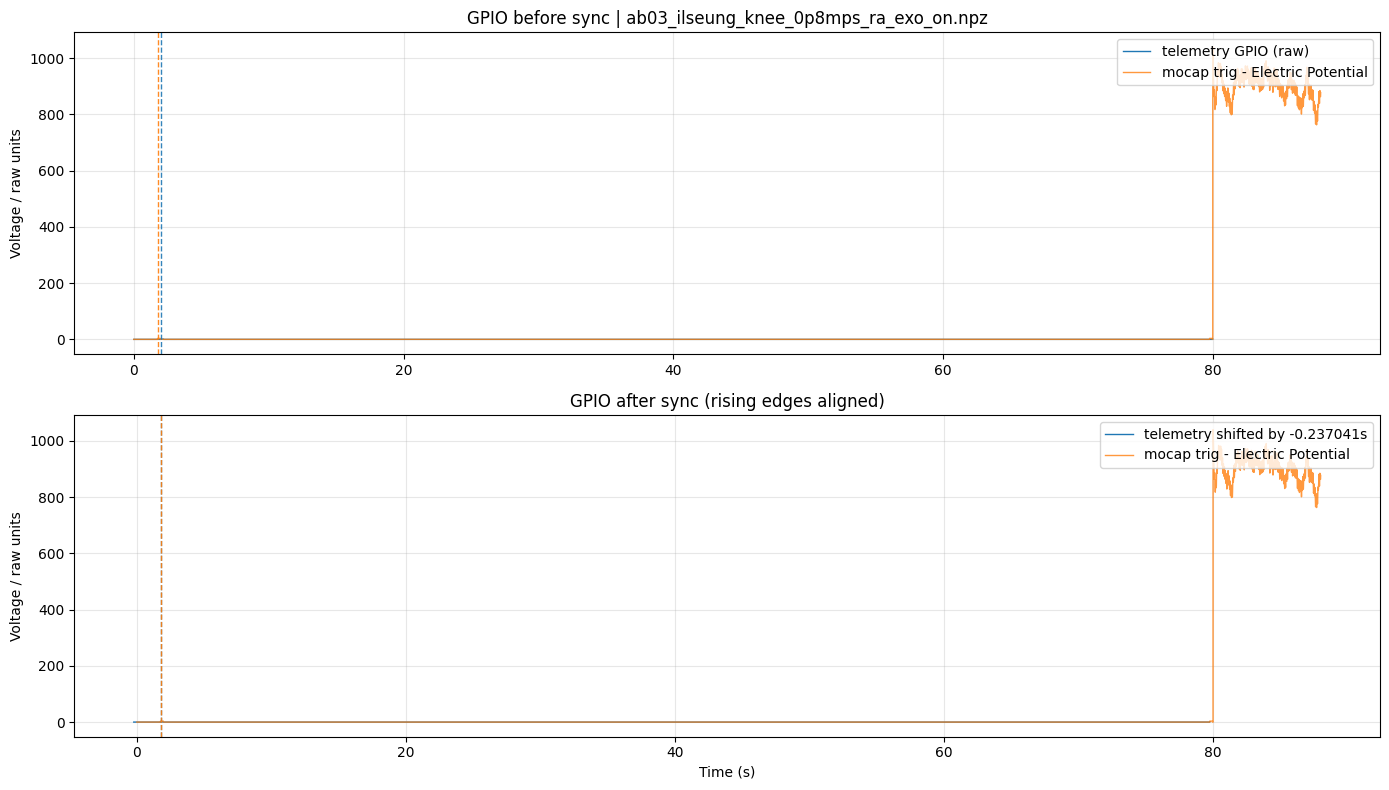

GPIO sync trial:   ab03_ilseung_knee_0p8mps_ra_exo_on.npz
Mocap file:        /home/metamobility3/Jinwoo/AB03_Ilseung/knee-exo/mocap/RA_0p8mps.csv
Rates (Hz):        exo=100.002, mocap=1000.000
Sync edge idx:     telemetry=199, mocap=1763
Offset (seconds):  -0.237041
Note: offset is applied in time (seconds), not by matching sample indices.


In [30]:
# GPIO sync diagnostics (interactive): telemetry vs mocap (before/after alignment)
# Uses first GPIO rising edge to estimate timeline offset.

if HIP_TELEMETRY_FILES:
    interactive_gpio_sync_plot(HIP_TELEMETRY_FILES, exo_kind='hip-exo', title_prefix='GPIO Debug (Hip)')
elif KNEE_TELEMETRY_FILES:
    interactive_gpio_sync_plot(KNEE_TELEMETRY_FILES, exo_kind='knee-exo', title_prefix='GPIO Debug (Knee)')

# Legacy static diagnostics kept for reference but disabled.
if False and HIP_TELEMETRY_FILES:
    GPIO_DEBUG_TELEMETRY_NPZ = HIP_TELEMETRY_FILES[0]
elif KNEE_TELEMETRY_FILES:
    GPIO_DEBUG_TELEMETRY_NPZ = KNEE_TELEMETRY_FILES[0]
else:
    GPIO_DEBUG_TELEMETRY_NPZ = None

if GPIO_DEBUG_TELEMETRY_NPZ is None:
    print('No telemetry file available for GPIO debug plot.')
else:
    fp = Path(GPIO_DEBUG_TELEMETRY_NPZ)
    stem = fp.stem.lower()
    if '_hip_' in stem:
        exo_kind = 'hip-exo'
    elif '_knee_' in stem:
        exo_kind = 'knee-exo'
    else:
        raise ValueError(f'Could not infer exo kind from filename: {fp.name}')

    d = np.load(str(fp), allow_pickle=True)
    keys = set(d.files)
    if 'time' in keys:
        t_npz = np.asarray(d['time'], dtype=np.float64)
    else:
        gpio_tmp = _extract_telemetry_gpio(d)
        t_npz = np.arange(len(gpio_tmp), dtype=np.float64)

    gpio_npz = _extract_telemetry_gpio(d).astype(np.float64)

    n = min(len(t_npz), len(gpio_npz))
    t_npz = t_npz[:n]
    gpio_npz = gpio_npz[:n]

    mocap_path = _resolve_mocap_csv_path(fp, exo_kind)
    t_mocap, gpio_mocap = _parse_mocap_trigger_csv(mocap_path)

    idx_npz = _first_falling_edge(gpio_npz)
    idx_mocap = _first_falling_edge(gpio_mocap)

    if idx_npz is None or idx_mocap is None:
        raise RuntimeError(
            f'Could not find GPIO sync edge (idx_npz={idx_npz}, idx_mocap={idx_mocap}) for {fp.name}'
        )

    offset_s = float(t_mocap[idx_mocap] - t_npz[idx_npz])
    t_npz_sync = t_npz + offset_s

    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    # Before sync
    axs[0].plot(t_npz, gpio_npz, lw=1.0, label='telemetry GPIO (raw)')
    axs[0].plot(t_mocap, gpio_mocap, lw=1.0, alpha=0.8, label='mocap trig - Electric Potential')
    axs[0].axvline(float(t_npz[idx_npz]), color='C0', ls='--', lw=1.0, alpha=0.9)
    axs[0].axvline(float(t_mocap[idx_mocap]), color='C1', ls='--', lw=1.0, alpha=0.9)
    axs[0].set_title(f'GPIO before sync | {fp.name}')
    axs[0].set_ylabel('Voltage / raw units')
    axs[0].grid(alpha=0.3)
    axs[0].legend(loc='upper right')

    # After sync (telemetry shifted by offset)
    axs[1].plot(t_npz_sync, gpio_npz, lw=1.0, label=f'telemetry shifted by {offset_s:+.6f}s')
    axs[1].plot(t_mocap, gpio_mocap, lw=1.0, alpha=0.8, label='mocap trig - Electric Potential')
    axs[1].axvline(float(t_npz_sync[idx_npz]), color='C0', ls='--', lw=1.0, alpha=0.9)
    axs[1].axvline(float(t_mocap[idx_mocap]), color='C1', ls='--', lw=1.0, alpha=0.9)
    axs[1].set_title('GPIO after sync (rising edges aligned)')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Voltage / raw units')
    axs[1].grid(alpha=0.3)
    axs[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    _fs_exo = infer_fs_hz(t_npz, default_fs=100.0)
    _fs_mocap = infer_fs_hz(t_mocap, default_fs=1000.0)
    print(f'GPIO sync trial:   {fp.name}')
    print(f'Mocap file:        {mocap_path}')
    print(f'Rates (Hz):        exo={_fs_exo:.3f}, mocap={_fs_mocap:.3f}')
    print(f'Sync edge idx:     telemetry={idx_npz}, mocap={idx_mocap}')
    print(f'Offset (seconds):  {offset_s:+.6f}')
    print('Note: offset is applied in time (seconds), not by matching sample indices.')

In [34]:
KNEE_BATCH_RESULTS = run_batch_eval(
    telemetry_files=KNEE_TELEMETRY_FILES,
    mode_cfgs=KNEE_CFGS,
    angle_key='model_in_knee_angle_raw',
    vel_key='model_in_knee_vel_raw',
    logged_out_key=KNEE_LOGGED_OUT_KEY,
    exo_kind='knee-exo',
)

print_batch_summary(KNEE_BATCH_RESULTS)

[OK] ab03_ilseung_knee_0p8mps_ra_exo_on.npz
[OK] ab03_ilseung_knee_0p8mps_rd_exo_on.npz


,trial,0512_ik_id_knee_compare_causal_in_no_out | R2,0512_ik_id_knee_compare_causal_in_no_out | RMSE,0512_ik_id_knee_deploy_causal_in_out | R2,0512_ik_id_knee_deploy_causal_in_out | RMSE,0512_ik_id_knee_offline_zero_phase | R2,0512_ik_id_knee_offline_zero_phase | RMSE
0,ab03_ilseung_knee_0p8mps_ra_exo_on.npz,0.6429,0.2172,0.0731,0.3499,0.6242,0.2228
1,ab03_ilseung_knee_0p8mps_rd_exo_on.npz,0.3745,0.2662,-0.7735,0.4482,0.5690,0.2210


In [ ]:
interactive_compare_plot(KNEE_BATCH_RESULTS, title_prefix='Knee Right')